In [10]:
import pandas as pd
file = "årsutfall.1997-2024.csv"

df = pd.read_csv(file, sep=";",
    encoding="utf-8-sig",
    engine="python")


In [11]:
import os
import re
import matplotlib


def save_commons_svg(
    fig,
    filename,
    folder="output",
    title=None,
    description=None,
    creator=None,
    clean_svg=True
):
    """
    Save a Matplotlib figure as a Wikimedia Commons-friendly SVG.
    """

    if fig is None:
        raise ValueError("Figure is None – kan inte spara SVG.")

    os.makedirs(folder, exist_ok=True)

    if not filename.lower().endswith(".svg"):
        filename += ".svg"

    path = os.path.join(folder, filename)

    # ---------------------------
    # Safe SVG metadata (whitelist only)
    # ---------------------------
    metadata = {}

    if title:
        metadata["Title"] = title

    if description:
        metadata["Description"] = description

    if creator:
        metadata["Creator"] = creator
    else:
        metadata["Creator"] = f"Matplotlib v{matplotlib.__version__}"

    # ---------------------------
    # Save SVG
    # ---------------------------
    fig.savefig(
        path,
        format="svg",
        bbox_inches="tight",
        transparent=True,
        metadata=metadata
    )

    # ---------------------------
    # Optional cleanup (remove RDF block)
    # ---------------------------
    if clean_svg:
        with open(path, "r", encoding="utf-8") as f:
            svg = f.read()

        svg = re.sub(r"<metadata>.*?</metadata>", "", svg, flags=re.DOTALL)
        svg = svg.strip()

        with open(path, "w", encoding="utf-8") as f:
            f.write(svg)

    print(f"Saved Commons SVG to: {path}")
    return path

In [12]:
num_cols = [
    "Statens budget",
    "Ändringsbudgetar",
    "Indragningar",
    "Utnyttjad del av medgivet överskridande",
    "Utfall",
    "Anslagskredit",
    "Ingående överföringsbelopp",
    "Utgående överföringsbelopp"
]

for col in num_cols:
    if col in df.columns:
        df[col] = df[col].apply(fix_number)

In [13]:
pd.options.display.float_format = '{:,.0f}'.format
df["Utfall_mdr"] = df["Utfall"] / 1_000

In [14]:
df_filtered = df[
    ~df["Utgiftsområdesnamn"].str.contains("tak", case=False, na=False) &
    ~df["Utgiftsområdesnamn"].str.contains("korrigering", case=False, na=False) &
    ~df["Utgiftsområdesnamn"].str.contains("nettoutlåning", case=False, na=False) &
    ~df["Utgiftsområdesnamn"].str.contains("Ålderspensionssystemet vid sidan av statens budget", case=False, na=False)
]
long = df_filtered.groupby(["År", "Utgiftsområdesnamn"])["Utfall_mdr"].sum().reset_index()
# long.groupby("Utgiftsområdesnamn")["Utfall_mdr"].std().sort_values(ascending=False).head(10)

Saved Commons SVG to: output/statsbudget_utgifter.svg


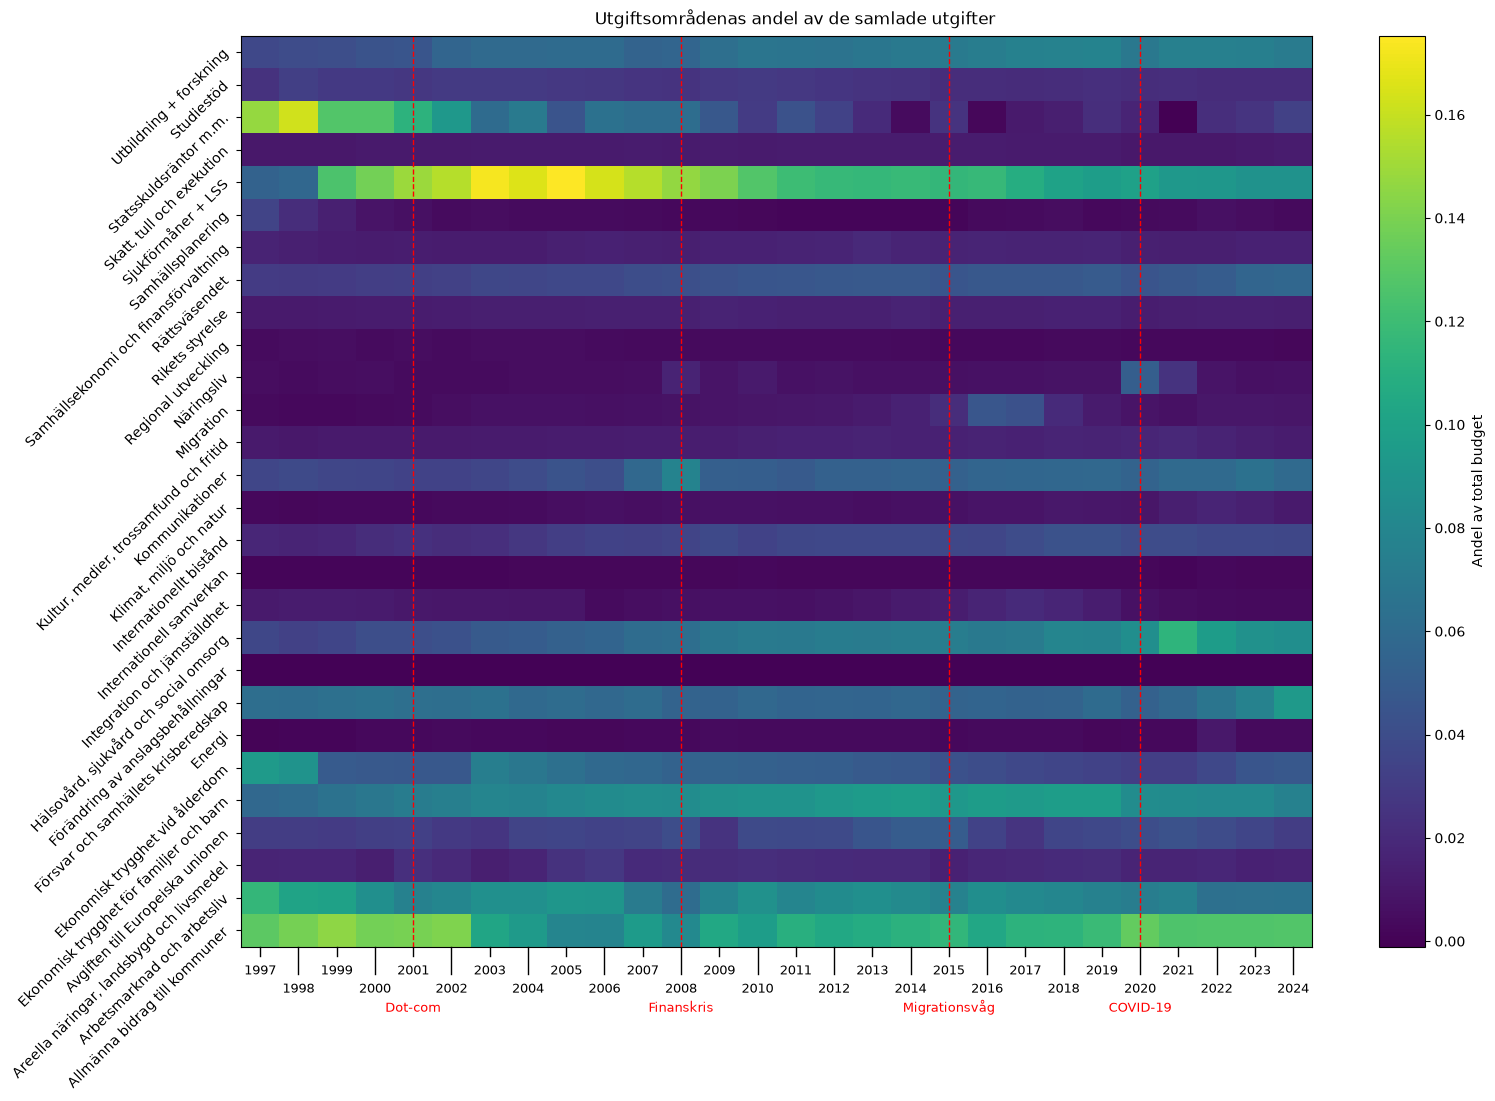

In [18]:
import os
import matplotlib.pyplot as plt

rename_map = {
    "Ekonomisk trygghet vid sjukdom och funktionsnedsättning": "Sjukförmåner + LSS",
    "Utbildning och universitetsforskning": "Utbildning + forskning",
    "Samhällsplanering, bostadsförsörjning och byggande samt konsumentpolitik": "Samhällsplanering"
}

df_filtered["Utgiftsområdesnamn"] = df_filtered["Utgiftsområdesnamn"].replace(rename_map)

base = df_filtered.groupby(["År", "Utgiftsområdesnamn"])["Utfall"].sum().reset_index()
pivot = base.pivot(index="År", columns="Utgiftsområdesnamn", values="Utfall").fillna(0)
share = pivot.div(pivot.sum(axis=1), axis=0)

events = {
    2001: "Dot-com",
    2008: "Finanskris",
    2015: "Migrationsvåg",
    2020: "COVID-19"
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "svg.fonttype": "none"
})

plt.rcdefaults()   # återställ alla rcParams
fig, ax = plt.subplots(
    figsize=(16, max(8, len(share.columns) * 0.4))
)

# ---------------------------
# FIX: proper pcolormesh grid
# ---------------------------
x = range(len(share.index) + 1)
y = range(len(share.columns) + 1)

im = ax.pcolormesh(
    x,
    y,
    share.T.values,
    cmap="viridis",
    shading="auto"
)

# ---------------------------
# AXES (FIXED ALIGNMENT)
# ---------------------------
# deaktivera native ticks vi ritar egna nedan
ax.set_xticks([])
ax.set_xticklabels([])

ax.set_yticks([i + 0.5 for i in range(len(share.columns))])
ax.set_yticklabels(share.columns, rotation=45, ha="right")

# ---------------------------
# YEAR LABELS BELOW GRID
# ---------------------------
for i, year in enumerate(share.index):
    is_upper = i % 2 == 0
    y_text = -0.02 if is_upper else -0.04

    ax.text(
        i + 0.5,
        y_text,
        str(year),
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=9
    )

    ax.plot(
        [i + 0.5, i + 0.5],
        [0.0, y_text + 0.01],
        transform=ax.get_xaxis_transform(),
        color="black",
        linewidth=1,
        clip_on=False
    )

# ---------------------------
# EVENTS (FIXED POSITIONING)
# ---------------------------
years = list(share.index)

for year, label in events.items():
    if year in years:
        x_pos = years.index(year) + 0.5

        ax.axvline(
            x=x_pos,
            color="red",
            linestyle="--",
            linewidth=1
        )

        ax.text(
            x_pos - 0,
            -2,
            label,
            color="red",
            fontsize=9,
            ha="center"
        )

# ---------------------------
# STYLE
# ---------------------------
fig.colorbar(im, ax=ax, label="Andel av total budget")

# ax.set_title(
#     "Utgiftsområdenas andel av de samlade utgifter",
#     pad=20
# )
fig.suptitle("Utgiftsområdenas andel av de samlade utgifter")
plt.tight_layout()

# ---------------------------
# EXPORT (Commons-safe)
# ---------------------------
save_commons_svg(
    fig,
    "statsbudget_utgifter.svg",
    title="Utgiftsområdenas andel av de samlade utgifter",
    description="Andel av statens budget per utgiftsområde och år"
)
plt.show()
plt.close(fig)
